<a href="https://colab.research.google.com/github/244107020170-png/machine-learning/blob/main/JS02_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import files
uploaded = files.upload()

import pandas as pd
df = pd.read_csv("JS02_data.csv")
df.head()

Saving JS02_data.csv to JS02_data.csv


,Full Name,Gender,City of Origin,Height (cm),Body Weight (kg),Previous Class,GPA Target (IPS)
0,Andi Pratama,M,Malang,172,68,TI-2A,3.40
1,Siti Rahmawati,F,Surabaya,160,52,TI-2B,3.50
2,Budi Santoso,M,Kediri,175,70,TI-2C,3.30
3,Rina Kartika,F,Blitar,158,50,TI-2A,3.45
4,Dimas Nugroho,M,Malang,180,75,TI-2B,3.60


In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
# Ganti path sesuai lokasi file di Drive
df = pd.read_csv("/content/drive/MyDrive/JS02_data.csv")
df.head()


Mounted at /content/drive


,Full Name,Gender,City of Origin,Height (cm),Body Weight (kg),Previous Class,GPA Target (IPS)
0,Andi Pratama,M,Malang,172,68,TI-2A,3.40
1,Siti Rahmawati,F,Surabaya,160,52,TI-2B,3.50
2,Budi Santoso,M,Kediri,175,70,TI-2C,3.30
3,Rina Kartika,F,Blitar,158,50,TI-2A,3.45
4,Dimas Nugroho,M,Malang,180,75,TI-2B,3.60


In [2]:
print(df.info())
print(df.describe())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Full Name         30 non-null     object 
 1   Gender            30 non-null     object 
 2   City of Origin    30 non-null     object 
 3   Height (cm)       30 non-null     int64  
 4   Body Weight (kg)  30 non-null     int64  
 5   Previous Class    30 non-null     object 
 6   GPA Target (IPS)  30 non-null     float64
dtypes: float64(1), int64(2), object(4)
memory usage: 1.8+ KB
None
       Height (cm)  Body Weight (kg)  GPA Target (IPS)
count    30.000000         30.000000         30.000000
mean    168.400000         61.833333          3.468333
std       7.708482          9.581172          0.095125
min     158.000000         49.000000          3.300000
25%     161.250000         53.000000          3.400000
50%     167.500000         61.000000          3.475000
75%     175.750000     

In [4]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Baca data dari Drive
df = pd.read_csv("/content/drive/MyDrive/JS02_data.csv")

# --- Preprocessing ---
# Encode kolom kategori (Gender, City, Previous Class)
label_cols = ["Gender", "City of Origin", "Previous Class"]
for col in label_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

# Normalisasi kolom numerik
scaler = StandardScaler()
num_cols = ["Height (cm)", "Body Weight (kg)", "GPA Target (IPS)"]
df[num_cols] = scaler.fit_transform(df[num_cols])

print("Data setelah preprocessing:")
print(df.head())

# --- Model sederhana ---
# Buang kolom Full Name (string)
X = df.drop(["Full Name", "GPA Target (IPS)"], axis=1)
y = df["GPA Target (IPS)"]

# Split train/test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Regresi Linear
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

# Evaluasi
score = model.score(X_test, y_test)
print("Akurasi (R^2):", score)

Data setelah preprocessing:
        Full Name  Gender  City of Origin  Height (cm)  Body Weight (kg)  \
0    Andi Pratama       1               4     0.475002          0.654626   
1  Siti Rahmawati       0               7    -1.108338         -1.043864   
2    Budi Santoso       1               3     0.870837          0.866938   
3    Rina Kartika       0               1    -1.372228         -1.256175   
4   Dimas Nugroho       1               4     1.530561          1.397716   

   Previous Class  GPA Target (IPS)  
0               0         -0.730630  
1               1          0.338585  
2               2         -1.799845  
3               0         -0.196023  
4               1          1.407799  
Akurasi (R^2): -0.05982719003769765


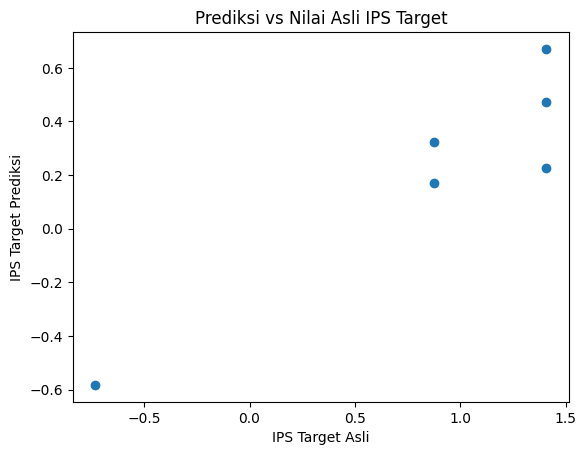

In [5]:
import matplotlib.pyplot as plt

# Prediksi
y_pred = model.predict(X_test)

# Scatter plot hasil prediksi vs nilai asli
plt.scatter(y_test, y_pred)
plt.xlabel("IPS Target Asli")
plt.ylabel("IPS Target Prediksi")
plt.title("Prediksi vs Nilai Asli IPS Target")
plt.show()
